In [1]:
# =========================================================
# AR5 單格點多變數 interval analysis
# - 讀取 AR5 日資料
# - 自動抓最近格點
# - 支援 tmean / tmin / tmax / pr
# - 計算 yearly / seasonal 天數變化
# - 只保留 2000-2036 完整模式
# - 畫 ensemble 圖（灰線=各模式，紅線=平均，紅虛線=趨勢）
# =========================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. 圖形字型設定
# =========================================================
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 1. 使用者設定區
# =========================================================

# 資料夾對應
VARIABLE_DIR_MAP = {
    "tmax": Path(r"C:\AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmean": Path(r"C:\AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmin": Path(r"C:\AR5_統計降尺度_日資料_臺北市_最低溫"),
    "pr": Path(r"C:\AR5_統計降尺度_日資料_臺北市_降雨量"),
}

# 變數英文顯示名稱
VARIABLE_LABEL_MAP = {
    "tmax": "Tmax",
    "tmean": "Tmean",
    "tmin": "Tmin",
    "pr": "Precipitation",
}

# 輸出資料夾
OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")#"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 單點座標（大學里）
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

# 分析年份
START_YEAR = 2000
END_YEAR = 2036

# RCP 情境
RCPS = ["rcp26", "rcp45", "rcp60", "rcp85"]

# 模式選擇：
# "all" / "365_only" / "ACCESS1-0" / ["ACCESS1-0", "CanESM2"]
MODEL_SELECTION = "365_only"

# 是否只保留 365 天模式
ONLY_365_MODELS = True

# 是否儲存表格
SAVE_TABLES = True

# AR5 缺值
INVALID_VALUE = -99.9

# AR5 中已知 360-day 模式
MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

# 分析區間
# (變數顯示名, 區間顯示名, variable_key, lower, upper, lower_inclusive, upper_inclusive)
TARGET_INTERVALS = [
    ("Tmean", "28–31°C", "tmean", 28, 31, True, False),
    ("Tmin",  "20–25°C", "tmin", 20, 25, True, False),
    ("Tmax",  "26–29°C", "tmax", 26, 29, True, False),
    ("Tmin",  "≥15.9°C", "tmin", 15.9, None, True, False),
]


# =========================================================
# 2. 標籤與檔名工具
# =========================================================
def make_display_label(var_label: str, range_label: str) -> str:
    return f"{var_label} {range_label}"


def make_safe_filename_label(var_label: str, range_label: str) -> str:
    text = f"{var_label}_{range_label}"
    text = text.replace(" ", "_")
    text = text.replace("≥", "ge")
    text = text.replace("≤", "le")
    text = text.replace("–", "_to_")
    text = text.replace("-", "_")
    text = text.replace("°C", "C")
    text = text.replace("°", "")
    text = text.replace(".", "_")
    text = text.replace("/", "_")
    return text


# =========================================================
# 3. 檔名解析與掃描
# =========================================================
def parse_filename(file_name: str):
    """
    解析檔名，例如：
    AR5_統計降尺度_日資料_臺北市_最高溫_historical_ACCESS1-0_1960.csv
    """
    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    return info


def scan_available_files(variable_dir: Path) -> pd.DataFrame:
    records = []

    for fp in variable_dir.glob("*.csv"):
        parsed = parse_filename(fp.name)
        if parsed is not None:
            parsed["path"] = str(fp)
            records.append(parsed)

    if not records:
        raise FileNotFoundError(f"在 {variable_dir} 找不到符合格式的 CSV 檔案")

    df = pd.DataFrame(records).sort_values(["model", "scenario", "year"]).reset_index(drop=True)
    return df


def get_available_models(file_index: pd.DataFrame):
    return sorted(file_index["model"].dropna().unique().tolist())


def filter_models(file_index: pd.DataFrame, model_selection="all", only_365_models=False):
    available_models = get_available_models(file_index)

    if model_selection == "all":
        selected = available_models
    elif model_selection == "365_only":
        selected = [m for m in available_models if m not in MODELS_360_DAY]
    elif isinstance(model_selection, str):
        selected = [model_selection]
    elif isinstance(model_selection, list):
        selected = model_selection
    else:
        raise ValueError("MODEL_SELECTION 設定錯誤")

    if only_365_models:
        selected = [m for m in selected if m not in MODELS_360_DAY]

    selected = [m for m in selected if m in available_models]

    if not selected:
        raise ValueError("篩選後沒有可用模式")

    return sorted(selected)


# =========================================================
# 4. 單檔讀取與最近格點
# =========================================================
def find_nearest_grid_row(df: pd.DataFrame, poi_lat: float, poi_lon: float) -> pd.Series:
    lon_col, lat_col = df.columns[:2]

    tmp = df.copy()
    tmp["dist"] = np.sqrt((tmp[lat_col] - poi_lat) ** 2 + (tmp[lon_col] - poi_lon) ** 2)

    idx = tmp["dist"].idxmin()
    return tmp.loc[idx].copy()


def row_to_daily_long(row: pd.Series, model: str, scenario: str, variable_key: str) -> pd.DataFrame:
    lon_col, lat_col = row.index[:2]
    lon_val = row[lon_col]
    lat_val = row[lat_col]

    date_cols = [c for c in row.index if re.fullmatch(r"\d{8}", str(c))]
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    out = pd.DataFrame({
        "date": pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce"),
        "value": values.values
    })

    out = out.dropna(subset=["date"]).copy()
    out["year"] = out["date"].dt.year
    out["month"] = out["date"].dt.month
    out["day"] = out["date"].dt.day
    out["doy"] = out["date"].dt.dayofyear
    out["model"] = model
    out["scenario"] = scenario
    out["variable"] = variable_key
    out["lon"] = lon_val
    out["lat"] = lat_val

    return out.reset_index(drop=True)


def read_single_file_as_long(file_path, model, scenario, variable_key, poi_lat, poi_lon):
    df = pd.read_csv(file_path, encoding="utf-8")
    row = find_nearest_grid_row(df, poi_lat=poi_lat, poi_lon=poi_lon)
    return row_to_daily_long(row, model=model, scenario=scenario, variable_key=variable_key)


# =========================================================
# 5. 建立單一變數 daily time series
# =========================================================
def build_daily_timeseries(
    variable_key,
    start_year,
    end_year,
    model_selection="all",
    only_365_models=False,
    poi_lat=25.0190099143756,
    poi_lon=121.53137177116402,
):
    variable_dir = VARIABLE_DIR_MAP[variable_key]
    file_index = scan_available_files(variable_dir)

    selected_models = filter_models(
        file_index=file_index,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    target_files = file_index[
        (file_index["year"] >= start_year) &
        (file_index["year"] <= end_year) &
        (file_index["scenario"].isin(["historical"] + RCPS)) &
        (file_index["model"].isin(selected_models))
    ].copy()

    if target_files.empty:
        raise ValueError(f"{variable_key} 沒有符合條件的檔案")

    parts = []

    print(f"\n=== 建立 {variable_key} daily time series ===")
    print(f"資料夾：{variable_dir}")
    print(f"年份：{start_year}-{end_year}")
    print(f"模式數：{len(selected_models)}")
    print(f"檔案數：{len(target_files)}")

    for _, row in target_files.sort_values(["model", "scenario", "year"]).iterrows():
        try:
            part = read_single_file_as_long(
                file_path=row["path"],
                model=row["model"],
                scenario=row["scenario"],
                variable_key=variable_key,
                poi_lat=poi_lat,
                poi_lon=poi_lon
            )
            parts.append(part)
            print(f"[OK] {row['model']} | {row['scenario']} | {row['year']}")
        except Exception as e:
            print(f"[FAIL] {row['model']} | {row['scenario']} | {row['year']} -> {e}")

    if not parts:
        raise RuntimeError(f"{variable_key} 全部檔案讀取失敗")

    daily_df = pd.concat(parts, ignore_index=True)
    daily_df = daily_df.sort_values(["model", "scenario", "date"]).reset_index(drop=True)

    year_count_df = (
        daily_df.groupby(["model", "scenario", "year"], as_index=False)
        .agg(
            n_days=("date", "count"),
            n_valid=("value", lambda x: x.notna().sum())
        )
        .sort_values(["model", "scenario", "year"])
        .reset_index(drop=True)
    )

    return daily_df, year_count_df


# =========================================================
# 6. 區間篩選
# =========================================================
def build_interval_mask(df, lower=None, upper=None, lower_inclusive=True, upper_inclusive=False):
    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= df["value"] >= lower
        else:
            mask &= df["value"] > lower

    if upper is not None:
        if upper_inclusive:
            mask &= df["value"] <= upper
        else:
            mask &= df["value"] < upper

    return mask


# =========================================================
# 7. Yearly / Seasonal 統計
# =========================================================
def calc_yearly_counts(
    daily_df,
    interval_name,
    lower,
    upper,
    lower_inclusive=True,
    upper_inclusive=False
):
    mask = build_interval_mask(
        daily_df,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive
    )

    sub = daily_df.loc[mask].copy()

    out = (
        sub.groupby(["model", "scenario", "year"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    out["interval_name"] = interval_name
    out["variable"] = daily_df["variable"].iloc[0]

    return out


def add_season_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    month_to_season = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }

    out["season"] = out["month"].map(month_to_season)
    out["season_year"] = out["year"]

    # 12 月歸到下一年冬季
    out.loc[out["month"] == 12, "season_year"] = out.loc[out["month"] == 12, "year"] + 1

    return out


def calc_seasonal_counts(
    daily_df,
    interval_name,
    lower,
    upper,
    lower_inclusive=True,
    upper_inclusive=False
):
    df = add_season_columns(daily_df)

    mask = build_interval_mask(
        df,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive
    )

    sub = df.loc[mask].copy()

    out = (
        sub.groupby(["model", "scenario", "season_year", "season"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    out["interval_name"] = interval_name
    out["variable"] = daily_df["variable"].iloc[0]

    return out


# =========================================================
# 8. 完整模式篩選
# =========================================================
def filter_complete_models_for_rcp(yearly_df, rcp, start_year=2000, end_year=2036):
    required_years = set(range(start_year, end_year + 1))
    valid_models = []

    sub = yearly_df[yearly_df["scenario"].isin(["historical", rcp])].copy()

    for model, g in sub.groupby("model"):
        years = set(g["year"].unique())
        if required_years.issubset(years):
            valid_models.append(model)

    return sorted(valid_models)


#def filter_complete_models_for_rcp_seasonal(seasonal_df, rcp, season, start_year=2000, end_year=2036):
  #  required_years = set(range(start_year, end_year + 1))
    #valid_models = []

   # sub = seasonal_df[
      #  (seasonal_df["scenario"].isin(["historical", rcp])) &
       # (seasonal_df["season"] == season)
#    ].copy()


   # sub = merge_scenario_by_year(sub_int, rcp)

    #sub = sub[sub["season"] == season].copy()
 #   for model, g in sub.groupby("model"):
     #   years = set(g["season_year"].unique())
       # if required_years.issubset(years):
      #      valid_models.append(model)

  #  return sorted(valid_models)

def merge_scenario_by_year(df, rcp, split_year=2005):
    """
    historical 到 split_year
    split_year+1 之後用指定 rcp
    """
    df = df.copy()

    cond = (
        ((df["season_year"] <= split_year) & (df["scenario"] == "historical")) |
        ((df["season_year"] > split_year) & (df["scenario"] == rcp))
    )

    return df.loc[cond].copy()


def filter_complete_models_for_rcp_seasonal(seasonal_df, rcp, season, start_year=2000, end_year=2036):
    required_years = set(range(start_year, end_year + 1))
    valid_models = []

    # 先正確拼接 historical + rcp
    sub = merge_scenario_by_year(seasonal_df, rcp)

    # 再選特定季節
    sub = sub[sub["season"] == season].copy()

    for model, g in sub.groupby("model"):
        years = set(g["season_year"].unique())
        if required_years.issubset(years):
            valid_models.append(model)

    return sorted(valid_models)



In [2]:
# =========================================================
# 11. 主流程
# =========================================================
def main():
    all_yearly = []
    all_seasonal = []
    daily_cache = {}

    needed_variables = sorted(set([item[2] for item in TARGET_INTERVALS]))
    print("需要讀取的變數：", needed_variables)

    # 每個變數只讀一次
    for var_key in needed_variables:
        daily_df, year_count_df = build_daily_timeseries(
            variable_key=var_key,
            start_year=START_YEAR,
            end_year=END_YEAR,
            model_selection=MODEL_SELECTION,
            only_365_models=ONLY_365_MODELS,
            poi_lat=POI_LAT,
            poi_lon=POI_LON,
        )

        daily_cache[var_key] = daily_df

        if SAVE_TABLES:
            year_count_path = OUTPUT_DIR / f"year_count_{var_key}_{START_YEAR}_{END_YEAR}.csv"
            year_count_df.to_csv(year_count_path, index=False, encoding="utf-8-sig")
            print(f"已存 year_count: {year_count_path}")

    # 依各區間統計 yearly + seasonal
    for var_label, range_label, var_key, lower, upper, lower_inclusive, upper_inclusive in TARGET_INTERVALS:
        df_var = daily_cache[var_key]
        display_name = make_display_label(var_label, range_label)

        yearly_df = calc_yearly_counts(
            daily_df=df_var,
            interval_name=display_name,
            lower=lower,
            upper=upper,
            lower_inclusive=lower_inclusive,
            upper_inclusive=upper_inclusive
        )

        seasonal_df = calc_seasonal_counts(
            daily_df=df_var,
            interval_name=display_name,
            lower=lower,
            upper=upper,
            lower_inclusive=lower_inclusive,
            upper_inclusive=upper_inclusive
        )

        all_yearly.append(yearly_df)
        all_seasonal.append(seasonal_df)

    yearly_counts_all = pd.concat(all_yearly, ignore_index=True)
    seasonal_counts_all = pd.concat(all_seasonal, ignore_index=True)

    yearly_counts_all = yearly_counts_all.sort_values(
        ["interval_name", "scenario", "model", "year"]
    ).reset_index(drop=True)

    seasonal_counts_all = seasonal_counts_all.sort_values(
        ["interval_name", "scenario", "season", "model", "season_year"]
    ).reset_index(drop=True)

    print("\n=== yearly_counts_all 預覽 ===")
    print(yearly_counts_all.head(20))

    print("\n=== seasonal_counts_all 預覽 ===")
    print(seasonal_counts_all.head(20))

    if SAVE_TABLES:
        yearly_out = OUTPUT_DIR / f"yearly_counts_all_intervals_{START_YEAR}_{END_YEAR}.csv"
        seasonal_out = OUTPUT_DIR / f"seasonal_counts_all_intervals_{START_YEAR}_{END_YEAR}.csv"

        yearly_counts_all.to_csv(yearly_out, index=False, encoding="utf-8-sig")
        seasonal_counts_all.to_csv(seasonal_out, index=False, encoding="utf-8-sig")

        print(f"已存 yearly_counts_all: {yearly_out}")
        print(f"已存 seasonal_counts_all: {seasonal_out}")


In [3]:
# =========================================================
# 12. 執行
# =========================================================
main()

需要讀取的變數： ['tmax', 'tmean', 'tmin']

=== 建立 tmax daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_最高溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK] ACCESS1-0 | rcp45 | 2015
[OK] ACCESS1-0 | rcp45 | 2016
[OK] ACCESS1-0 | rcp45 | 2017
[OK] ACCESS1-0 | rcp45 | 2018
[OK] ACCESS1-0 | rcp45 | 2019
[OK] ACCESS1-0 | rcp45 | 2020
[OK] ACCESS1-0 | rcp45 | 2021
[OK] ACCESS1-0 | rcp45 | 2022
[OK] ACCESS1-0 | rcp45 | 2023
[OK] ACCESS1-0 | rcp45 | 2024
[OK] ACCESS1-0 | rcp45 | 2025
[OK] ACCESS1-0 | rcp45 | 2026
[OK] ACCESS1-0 | rcp45 | 2027
[O

In [4]:
#檢查模式缺失
# =========================================================
# A. 檢查不同 RCP 的模式缺失情況（不畫圖版）
# 依賴你前面已經定義好的：
# - VARIABLE_DIR_MAP
# - scan_available_files
# - filter_models
# - RCPS
# - MODELS_360_DAY
# =========================================================

def get_file_index_for_variable(variable_key, model_selection="all", only_365_models=False):
    """
    讀取某一變數的所有檔案索引，只看檔名，不讀 CSV 內容。
    """
    variable_dir = VARIABLE_DIR_MAP[variable_key]
    file_index = scan_available_files(variable_dir)

    selected_models = filter_models(
        file_index=file_index,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    file_index = file_index[file_index["model"].isin(selected_models)].copy()
    file_index = file_index.sort_values(["model", "scenario", "year"]).reset_index(drop=True)
    return file_index


def expected_years_for_scenario(scenario, start_year=2000, end_year=2036, split_year=2005):
    """
    回傳某個 scenario 理論上應該出現的年份集合
    """
    if scenario == "historical":
        return set(range(start_year, min(end_year, split_year) + 1))
    else:
        return set(range(max(start_year, split_year + 1), end_year + 1))


def summarize_missing_years_by_scenario(
    variable_key,
    start_year=2000,
    end_year=2036,
    model_selection="all",
    only_365_models=False,
    split_year=2005
):
    """
    檢查每個 model 在各 scenario 下缺哪些年份
    只看檔案是否存在，不讀 daily data。
    """

    file_index = get_file_index_for_variable(
        variable_key=variable_key,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    scenarios_to_check = ["historical"] + RCPS
    results = []

    for scenario in scenarios_to_check:
        expected = expected_years_for_scenario(
            scenario=scenario,
            start_year=start_year,
            end_year=end_year,
            split_year=split_year
        )

        sub = file_index[file_index["scenario"] == scenario].copy()

        for model in sorted(file_index["model"].unique()):
            years = set(sub.loc[sub["model"] == model, "year"].tolist())
            missing_years = sorted(expected - years)
            available_years = sorted(expected & years)

            results.append({
                "variable": variable_key,
                "model": model,
                "scenario": scenario,
                "expected_n_years": len(expected),
                "available_n_years": len(available_years),
                "missing_n_years": len(missing_years),
                "is_complete": len(missing_years) == 0,
                "missing_years": missing_years,
                "available_years": available_years,
            })

    summary_df = pd.DataFrame(results)
    return summary_df


def summarize_transition_completeness(
    variable_key,
    rcps=None,
    start_year=2000,
    end_year=2036,
    model_selection="all",
    only_365_models=False,
    split_year=2005
):
    """
    檢查 historical + 各 RCP 在 2000–2036 是否能無縫接起來
    這個最適合回答：
    「歷史接不上 rcp，中間年份有落差會不會被排掉？」
    """

    if rcps is None:
        rcps = RCPS

    file_index = get_file_index_for_variable(
        variable_key=variable_key,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    expected_hist = set(range(start_year, min(end_year, split_year) + 1))
    expected_future = set(range(max(start_year, split_year + 1), end_year + 1))
    expected_all = set(range(start_year, end_year + 1))

    results = []

    models = sorted(file_index["model"].unique())

    for rcp in rcps:
        for model in models:
            hist_years = set(
                file_index.loc[
                    (file_index["model"] == model) &
                    (file_index["scenario"] == "historical"),
                    "year"
                ].tolist()
            )
            fut_years = set(
                file_index.loc[
                    (file_index["model"] == model) &
                    (file_index["scenario"] == rcp),
                    "year"
                ].tolist()
            )

            hist_missing = sorted(expected_hist - hist_years)
            fut_missing = sorted(expected_future - fut_years)

            merged_years = (hist_years & expected_hist) | (fut_years & expected_future)
            merged_missing = sorted(expected_all - merged_years)

            results.append({
                "variable": variable_key,
                "model": model,
                "rcp": rcp,
                "hist_missing_n": len(hist_missing),
                "future_missing_n": len(fut_missing),
                "merged_missing_n": len(merged_missing),
                "transition_complete": len(merged_missing) == 0,
                "hist_missing_years": hist_missing,
                "future_missing_years": fut_missing,
                "merged_missing_years": merged_missing,
            })

    transition_df = pd.DataFrame(results)
    return transition_df


def print_missing_summary(summary_df, show_only_incomplete=True, max_rows=50):
    """
    比較好閱讀的文字輸出
    """
    df = summary_df.copy()

    if show_only_incomplete:
        if "transition_complete" in df.columns:
            df = df[~df["transition_complete"]].copy()
        elif "is_complete" in df.columns:
            df = df[~df["is_complete"]].copy()

    if df.empty:
        print("沒有缺失，全部完整。")
        return

    print(df.head(max_rows).to_string(index=False))


def list_complete_models_by_rcp(transition_df):
    """
    回傳每個 RCP 下哪些 model 是完整的
    """
    out = (
        transition_df.groupby("rcp")
        .apply(lambda x: sorted(x.loc[x["transition_complete"], "model"].tolist()))
        .to_dict()
    )
    return out

In [5]:
# =========================================================
# AR5 t-test 前的最終模式篩選（接 coverage 檢查結果）
# 目的：
# 1. 排除 360_day 模式
# 2. 只保留 historical + 各 RCP 年份完整銜接的模式
# 3. 建立每個 RCP 可直接拿去做 t-test 的 final models
# =========================================================

from pathlib import Path
import pandas as pd

# ---------------------------------------------------------
# 0. 變數設定：你可以改這裡
# ---------------------------------------------------------
VARIABLE_KEY = "tmean"   # "tmean" / "tmin" / "tmax" / "pr"
START_YEAR   = 2000
END_YEAR     = 2036
SPLIT_YEAR   = 2005

# 這裡建議直接開 True，因為你現在明確要排除 360_day
ONLY_365_MODELS = True

# 如果你前面已有 MODEL_SELECTION，就沿用；沒有就設成 "all"
try:
    MODEL_SELECTION
except NameError:
    MODEL_SELECTION = "all"

# ---------------------------------------------------------
# 1. 跑 transition completeness 檢查
#    -> 只保留 historical + rcp 可以完整接起來的模式
# ---------------------------------------------------------
transition_check = summarize_transition_completeness(
    variable_key=VARIABLE_KEY,
    start_year=START_YEAR,
    end_year=END_YEAR,
    model_selection=MODEL_SELECTION,
    only_365_models=ONLY_365_MODELS,
    split_year=SPLIT_YEAR
)

print("=== 不完整的模式（只顯示 incomplete）===")
print_missing_summary(transition_check, show_only_incomplete=True, max_rows=200)

# ---------------------------------------------------------
# 2. 依各 RCP 取出完整模式
# ---------------------------------------------------------
final_models_by_rcp = list_complete_models_by_rcp(transition_check)

print("\n=== 每個 RCP 可直接用於 t-test 的 final models ===")
for rcp, models in final_models_by_rcp.items():
    print(f"\n{rcp}: {len(models)} models")
    print(models)

# ---------------------------------------------------------
# 3. 另外整理成 DataFrame，方便你後續查表/輸出
# ---------------------------------------------------------
final_models_table = (
    transition_check.loc[transition_check["transition_complete"], ["rcp", "model"]]
    .sort_values(["rcp", "model"])
    .reset_index(drop=True)
)

print("\n=== final_models_table ===")
display(final_models_table)

# ---------------------------------------------------------
# 4. 如果你想找「所有 RCP 都共同完整」的模式，也一起列出來
#    （這個是交集；只有你之後想做所有情境都一致比較時才用）
# ---------------------------------------------------------
common_models_all_rcp = sorted(
    set(final_models_by_rcp.get("rcp26", []))
    & set(final_models_by_rcp.get("rcp45", []))
    & set(final_models_by_rcp.get("rcp60", []))
    & set(final_models_by_rcp.get("rcp85", []))
)

print("\n=== 所有 RCP 都完整的共同模式 ===")
print(f"{len(common_models_all_rcp)} models")
print(common_models_all_rcp)

# ---------------------------------------------------------
# 5. 建立後面 t-test 會直接用到的變數
# ---------------------------------------------------------
FINAL_MODELS_RCP26 = final_models_by_rcp.get("rcp26", [])
FINAL_MODELS_RCP45 = final_models_by_rcp.get("rcp45", [])
FINAL_MODELS_RCP60 = final_models_by_rcp.get("rcp60", [])
FINAL_MODELS_RCP85 = final_models_by_rcp.get("rcp85", [])

FINAL_MODELS_COMMON = common_models_all_rcp

=== 不完整的模式（只顯示 incomplete）===
variable        model   rcp  hist_missing_n  future_missing_n  merged_missing_n  transition_complete hist_missing_years                                                                                                                                                                       future_missing_years                                                                                                                                                                       merged_missing_years
   tmean    ACCESS1-0 rcp26               0                31                31                False                 [] [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036] [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 

C:\Users\user\AppData\Local\Temp\ipykernel_18300\3017098621.py:190: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sorted(x.loc[x["transition_complete"], "model"].tolist()))


,rcp,model
0,rcp26,BNU-ESM
1,rcp26,CCSM4
2,rcp26,CESM1-CAM5
3,rcp26,CNRM-CM5
4,rcp26,CSIRO-Mk3-6-0
...,...,...
87,rcp85,MRI-ESM1
88,rcp85,NorESM1-M
89,rcp85,bcc-csm1-1
90,rcp85,bcc-csm1-1-m



=== 所有 RCP 都完整的共同模式 ===
13 models
['CCSM4', 'CESM1-CAM5', 'CSIRO-Mk3-6-0', 'GFDL-ESM2G', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m']


In [6]:
# =========================================================
# AR5 tmean：依 coverage 篩選後的模式做 t-test
# historical vs each RCP
# =========================================================

from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

# -------------------------------
# 0. 你剛剛篩好的 final models
# -------------------------------
final_models_by_rcp = {
    "rcp26": ['BNU-ESM', 'CCSM4', 'CESM1-CAM5', 'CNRM-CM5', 'CSIRO-Mk3-6-0',
              'CanESM2', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'IPSL-CM5A-LR',
              'IPSL-CM5A-MR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5',
              'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'NorESM1-M',
              'bcc-csm1-1', 'bcc-csm1-1-m'],

    "rcp45": ['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC',
              'CESM1-CAM5', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5',
              'CSIRO-Mk3-6-0', 'CanESM2', 'FGOALS-g2', 'GFDL-ESM2G',
              'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR',
              'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR',
              'MPI-ESM-MR', 'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1',
              'bcc-csm1-1-m', 'inmcm4'],

    "rcp60": ['CCSM4', 'CESM1-CAM5', 'CSIRO-Mk3-6-0', 'GFDL-CM3',
              'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR',
              'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MRI-CGCM3',
              'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m'],

    "rcp85": ['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC',
              'CESM1-CAM5', 'CMCC-CESM', 'CMCC-CM', 'CNRM-CM5',
              'CSIRO-Mk3-6-0', 'CanESM2', 'EC-EARTH', 'FGOALS-g2',
              'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR',
              'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM',
              'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR',
              'MRI-CGCM3', 'MRI-ESM1', 'NorESM1-M', 'bcc-csm1-1',
              'bcc-csm1-1-m', 'inmcm4']
}

# -------------------------------
# 1. 設定
# -------------------------------
VARIABLE_KEY = "tmin"
hist_start = 2000
hist_end   = 2005
fut_start  = 2006
fut_end    = 2036

# 把四個 RCP 所有會用到的模式先合併，避免重複讀檔
all_needed_models = sorted(set(
    m for models in final_models_by_rcp.values() for m in models
))

print(f"需要讀取的模式數: {len(all_needed_models)}")
print(all_needed_models)

# -------------------------------
# 2. 讀取 tmean 日資料
#    這裡直接接你 notebook 既有函式
# -------------------------------
daily_tmean_df, year_count_tmean_df = build_daily_timeseries(
    variable_key=VARIABLE_KEY,
    start_year=hist_start,
    end_year=fut_end,
    model_selection=all_needed_models,   # 只讀需要的模式
    only_365_models=True,                # 排除 360_day
    poi_lat=POI_LAT,
    poi_lon=POI_LON,
)

print("\n=== daily_tmean_df ===")
display(daily_tmean_df.head())

print("\n=== year_count_tmean_df ===")
display(year_count_tmean_df.head())

# -------------------------------
# 3. 從 daily 轉成年平均 tmean
# -------------------------------
annual_tmean_df = (
    daily_tmean_df
    .groupby(["model", "scenario", "year"], as_index=False)
    .agg(
        annual_mean=("value", "mean"),
        n_valid=("value", lambda x: x.notna().sum())
    )
    .sort_values(["model", "scenario", "year"])
    .reset_index(drop=True)
)

print("\n=== annual_tmean_df ===")
display(annual_tmean_df.head(20))


def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof
    )
    return (np.mean(y) - np.mean(x)) / pooled_std

def mean_ci(x):
    mean = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x))
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se
    return mean, ci_low, ci_high
# -------------------------------
# 4. 做 t-test
#    每個 RCP 都拿自己的 final models 跟 historical 比
# -------------------------------
results = []

for rcp, model_list in final_models_by_rcp.items():
    print(f"\n===== {rcp} =====")

    for model in model_list:
        hist = annual_tmean_df[
            (annual_tmean_df["model"] == model) &
            (annual_tmean_df["scenario"] == "historical") &
            (annual_tmean_df["year"].between(hist_start, hist_end))
        ]["annual_mean"].dropna().values

        fut = annual_tmean_df[
            (annual_tmean_df["model"] == model) &
            (annual_tmean_df["scenario"] == rcp) &
            (annual_tmean_df["year"].between(fut_start, fut_end))
        ]["annual_mean"].dropna().values

        if len(hist) < 2 or len(fut) < 2:
            print(f"[SKIP] {model} | {rcp}: insufficient annual data")
            continue

        t_stat, p_val = ttest_ind(hist, fut, equal_var=False)
        effect_size = cohens_d(hist, fut)
        hist_mean, hist_low, hist_high = mean_ci(hist)
        fut_mean, fut_low, fut_high = mean_ci(fut)

        results.append({
            "variable": VARIABLE_KEY,
            "model": model,
            "rcp": rcp,
            "hist_n": len(hist),
            "fut_n": len(fut),
            "hist_mean": np.mean(hist),
            "fut_mean": np.mean(fut),
            "mean_diff": np.mean(fut) - np.mean(hist),
            "t_stat": t_stat,
            "p_value": p_val,
            "significant": p_val < 0.05,
            "effect_size": effect_size,
            "hist_ci_low": hist_low,
            "hist_ci_high": hist_high,
            "fut_ci_low": fut_low,
            "fut_ci_high": fut_high,
        })

df_ttest = pd.DataFrame(results).sort_values(["rcp", "model"]).reset_index(drop=True)

print("\n=== t-test 結果 ===")
display(df_ttest)

# -------------------------------
# 5. 每個 RCP 的顯著模式統計
# -------------------------------
summary_ttest = (
    df_ttest.groupby("rcp")["significant"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "significant_models", "count": "total_models"})
)

summary_ttest["significant_ratio"] = (
    summary_ttest["significant_models"] / summary_ttest["total_models"]
)

print("\n=== 各 RCP 顯著模式比例 ===")
display(summary_ttest)

需要讀取的模式數: 31
['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC', 'CESM1-CAM5', 'CMCC-CESM', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'EC-EARTH', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'MRI-ESM1', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4']

=== 建立 tmin daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_最低溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK]

,date,value,year,month,day,doy,model,scenario,variable,lon,lat
0,2000-01-01,17.7144,2000,1,1,1,ACCESS1-0,historical,tmin,121.55,25.0
1,2000-01-02,18.0024,2000,1,2,2,ACCESS1-0,historical,tmin,121.55,25.0
2,2000-01-03,10.2460,2000,1,3,3,ACCESS1-0,historical,tmin,121.55,25.0
3,2000-01-04,9.4120,2000,1,4,4,ACCESS1-0,historical,tmin,121.55,25.0
4,2000-01-05,10.8715,2000,1,5,5,ACCESS1-0,historical,tmin,121.55,25.0



=== year_count_tmean_df ===


,model,scenario,year,n_days,n_valid
0,ACCESS1-0,historical,2000,365,365
1,ACCESS1-0,historical,2001,365,365
2,ACCESS1-0,historical,2002,365,365
3,ACCESS1-0,historical,2003,365,365
4,ACCESS1-0,historical,2004,365,365



=== annual_tmean_df ===


,model,scenario,year,annual_mean,n_valid
0,ACCESS1-0,historical,2000,20.230492,365
1,ACCESS1-0,historical,2001,19.056217,365
2,ACCESS1-0,historical,2002,19.403087,365
3,ACCESS1-0,historical,2003,19.484185,365
4,ACCESS1-0,historical,2004,20.147968,365
5,ACCESS1-0,historical,2005,19.971519,365
6,ACCESS1-0,rcp45,2006,19.701071,365
7,ACCESS1-0,rcp45,2007,19.953111,365
8,ACCESS1-0,rcp45,2008,20.416596,365
9,ACCESS1-0,rcp45,2009,19.966946,365



===== rcp26 =====

===== rcp45 =====

===== rcp60 =====

===== rcp85 =====

=== t-test 結果 ===


,variable,model,rcp,hist_n,fut_n,hist_mean,fut_mean,mean_diff,t_stat,p_value,significant,effect_size,hist_ci_low,hist_ci_high,fut_ci_low,fut_ci_high
0,tmin,BNU-ESM,rcp26,6,31,19.838227,20.178979,0.340752,-1.724613,0.128719,False,0.788857,19.481724,20.194730,20.027730,20.330228
1,tmin,CCSM4,rcp26,6,31,19.609823,19.984290,0.374467,-3.019516,0.010138,True,0.913400,19.420237,19.799409,19.832170,20.136409
2,tmin,CESM1-CAM5,rcp26,6,31,19.243472,20.101955,0.858484,-2.544688,0.043841,True,1.444375,18.611788,19.875156,19.906501,20.297410
3,tmin,CNRM-CM5,rcp26,6,31,19.962114,19.732258,-0.229856,1.186838,0.271497,False,-0.498186,19.619926,20.304302,19.567942,19.896574
4,tmin,CSIRO-Mk3-6-0,rcp26,6,31,19.367592,20.187133,0.819541,-3.982655,0.003100,True,1.430044,19.022589,19.712594,19.978223,20.396044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,tmin,MRI-ESM1,rcp85,6,31,19.321278,19.752242,0.430964,-4.072642,0.000485,True,1.011562,19.189618,19.452939,19.591984,19.912500
88,tmin,NorESM1-M,rcp85,6,31,19.289876,19.909923,0.620047,-2.267861,0.063413,False,1.260504,18.779400,19.800352,19.746898,20.072948
89,tmin,bcc-csm1-1,rcp85,6,31,19.735112,20.182437,0.447325,-1.424443,0.198834,False,0.671604,19.164846,20.305378,19.950817,20.414058
90,tmin,bcc-csm1-1-m,rcp85,6,31,19.537980,20.139040,0.601060,-2.901188,0.016430,True,1.008468,19.195464,19.880496,19.920926,20.357154



=== 各 RCP 顯著模式比例 ===


,significant_models,total_models,significant_ratio
rcp,,,
rcp26,13,20,0.650000
rcp45,14,27,0.518519
rcp60,7,15,0.466667
rcp85,18,30,0.600000


rcp
rcp26    float64
rcp45    float64
rcp60    float64
rcp85    float64
dtype: object


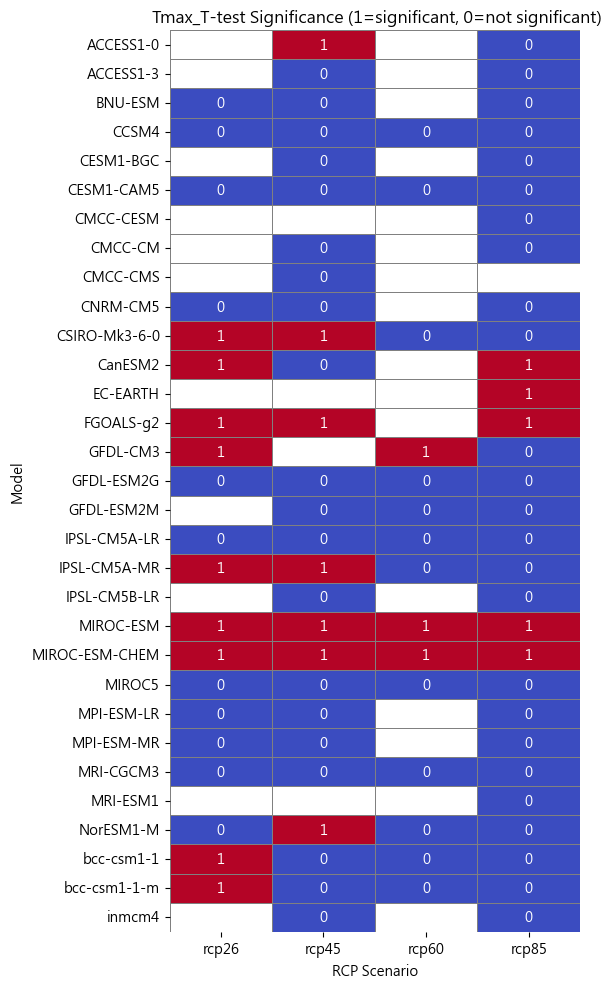

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

output_dir= Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels")
output_dir.mkdir(exist_ok=True)
# 先複製，避免動到原表
plot_df = df_ttest.copy()

# 把 significant 明確轉成數值
plot_df["significant_num"] = plot_df["significant"].astype(float)
# True -> 1.0, False -> 0.0

# pivot 成 model × rcp
heatmap_data = plot_df.pivot(
    index="model",
    columns="rcp",
    values="significant_num"
)

print(heatmap_data.dtypes)   # 檢查一下應該都是 float

plt.figure(figsize=(6, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    cbar=False,
    linewidths=0.5,
    linecolor="gray"
)

plt.title(" Tmax_T-test Significance (1=significant, 0=not significant)")
plt.xlabel("RCP Scenario")
plt.ylabel("Model")
plt.tight_layout()
#outpath = output_dir / f"{VARIABLE_KEY}_T-test Significance (1=significant, 0=not significant).png"
outpath = output_dir / f"{VARIABLE_KEY}_ttest_sig_1vs0.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()


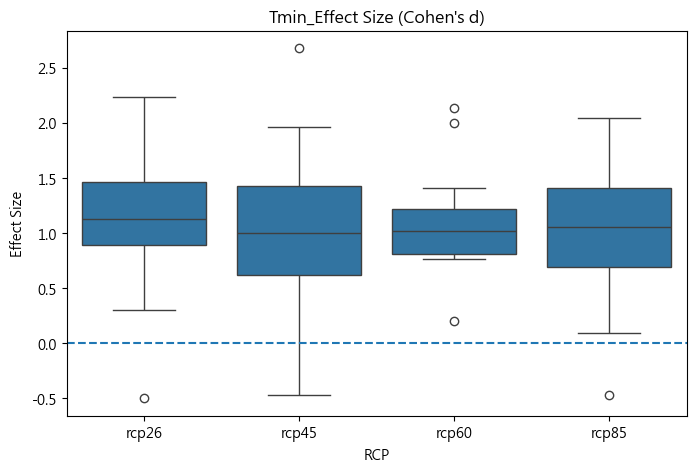

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_ttest,
    x="rcp",
    y="effect_size"
)

plt.axhline(0, linestyle="--")

plt.title("Tmin_Effect Size (Cohen's d)")
plt.ylabel("Effect Size")
plt.xlabel("RCP")
outpath = output_dir / f"{VARIABLE_KEY}_Effect Size (Cohen's d).png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

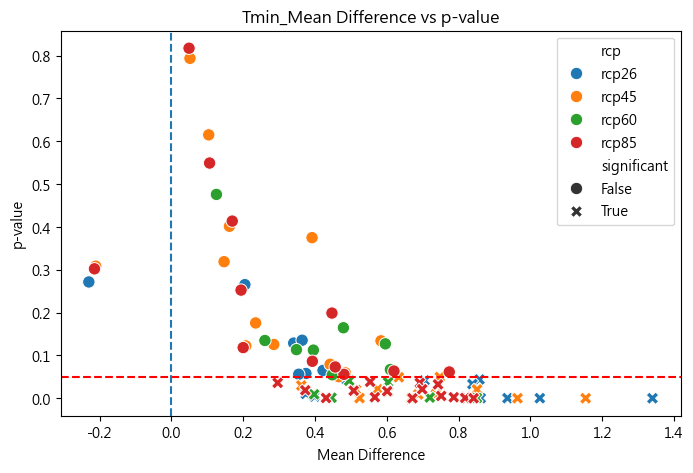

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_ttest,
    x="mean_diff",
    y="p_value",
    hue="rcp",
    style="significant",
    s=80
)

plt.axhline(0.05, linestyle="--", color="red")
plt.axvline(0, linestyle="--")

plt.title("Tmin_Mean Difference vs p-value")
plt.xlabel("Mean Difference")
plt.ylabel("p-value")
outpath = output_dir / f"{VARIABLE_KEY}_Mean Difference vs p-value.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

,rcp,significant_ratio,mean_diff_mean,mean_diff_std,effect_size_mean,effect_size_std,n_models
0,rcp26,0.650000,0.586514,0.354017,1.132856,0.588136,20
1,rcp45,0.518519,0.484176,0.301434,1.014175,0.650835,27
2,rcp60,0.466667,0.506304,0.198413,1.085294,0.489343,15
3,rcp85,0.600000,0.495476,0.262243,1.013011,0.548405,30


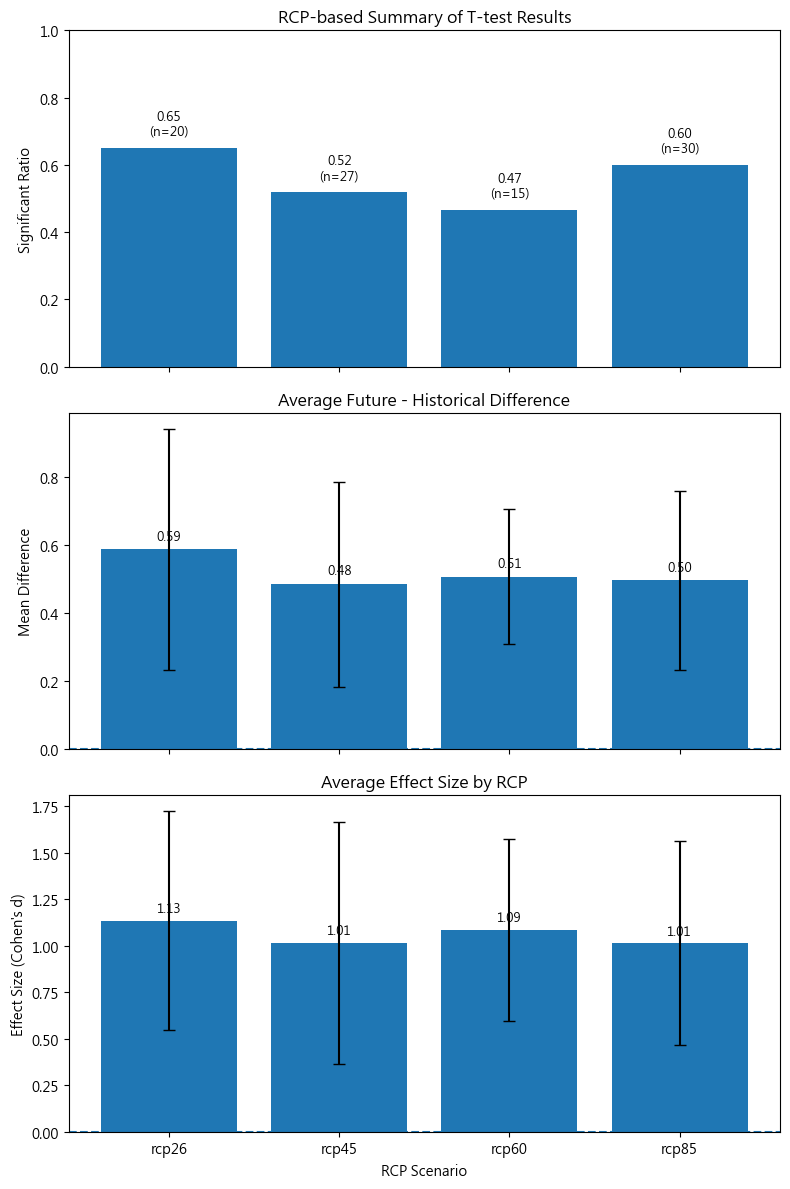

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 確保欄位型態正確
plot_df = df_ttest.copy()
plot_df["mean_diff"] = pd.to_numeric(plot_df["mean_diff"], errors="coerce")
plot_df["p_value"] = pd.to_numeric(plot_df["p_value"], errors="coerce")
plot_df["significant"] = plot_df["significant"].astype(bool)

# 如果 effect_size 還沒算過，先補一欄空值避免報錯
if "effect_size" not in plot_df.columns:
    plot_df["effect_size"] = np.nan

plot_df["effect_size"] = pd.to_numeric(plot_df["effect_size"], errors="coerce")

# 依 RCP 統整
summary_rcp = (
    plot_df.groupby("rcp", as_index=False)
    .agg(
        significant_ratio=("significant", "mean"),
        mean_diff_mean=("mean_diff", "mean"),
        mean_diff_std=("mean_diff", "std"),
        effect_size_mean=("effect_size", "mean"),
        effect_size_std=("effect_size", "std"),
        n_models=("model", "count")
    )
)

# 固定 RCP 順序
rcp_order = ["rcp26", "rcp45", "rcp60", "rcp85"]
summary_rcp["rcp"] = pd.Categorical(summary_rcp["rcp"], categories=rcp_order, ordered=True)
summary_rcp = summary_rcp.sort_values("rcp").reset_index(drop=True)

display(summary_rcp)

# 畫圖
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# 1. 顯著比例
axes[0].bar(summary_rcp["rcp"], summary_rcp["significant_ratio"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Significant Ratio")
axes[0].set_title("RCP-based Summary of T-test Results")

for i, row in summary_rcp.iterrows():
    axes[0].text(i, row["significant_ratio"] + 0.03,
                 f'{row["significant_ratio"]:.2f}\n(n={int(row["n_models"])})',
                 ha="center", va="bottom", fontsize=9)

# 2. 平均溫度差
axes[1].bar(summary_rcp["rcp"], summary_rcp["mean_diff_mean"],
            yerr=summary_rcp["mean_diff_std"], capsize=4)
axes[1].axhline(0, linestyle="--")
axes[1].set_ylabel("Mean Difference")
axes[1].set_title("Average Future - Historical Difference")

for i, row in summary_rcp.iterrows():
    axes[1].text(i, row["mean_diff_mean"] + 0.02,
                 f'{row["mean_diff_mean"]:.2f}',
                 ha="center", va="bottom", fontsize=9)

# 3. 平均 effect size
axes[2].bar(summary_rcp["rcp"], summary_rcp["effect_size_mean"],
            yerr=summary_rcp["effect_size_std"], capsize=4)
axes[2].axhline(0, linestyle="--")
axes[2].set_ylabel("Effect Size (Cohen's d)")
axes[2].set_xlabel("RCP Scenario")
axes[2].set_title("Average Effect Size by RCP")

for i, row in summary_rcp.iterrows():
    if pd.notna(row["effect_size_mean"]):
        axes[2].text(i, row["effect_size_mean"] + 0.03,
                     f'{row["effect_size_mean"]:.2f}',
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

def run_ttest_for_variable(
    variable_key,
    final_models_by_rcp,
    hist_start,
    hist_end,
    fut_start,
    fut_end,
    poi_lat,
    poi_lon
):
    # 1. 合併所有需要的模式
    all_needed_models = sorted(set(
        m for models in final_models_by_rcp.values() for m in models
    ))

    print(f"\n===== Running {variable_key} =====")
    print(f"需要讀取的模式數: {len(all_needed_models)}")

    # 2. 讀取 daily data
    daily_df, year_count_df = build_daily_timeseries(
        variable_key=variable_key,
        start_year=hist_start,
        end_year=fut_end,
        model_selection=all_needed_models,
        only_365_models=True,
        poi_lat=poi_lat,
        poi_lon=poi_lon,
    )

    # 3. 轉成年平均
    annual_df = (
        daily_df
        .groupby(["model", "scenario", "year"], as_index=False)
        .agg(
            annual_mean=("value", "mean"),
            n_valid=("value", lambda x: x.notna().sum())
        )
        .sort_values(["model", "scenario", "year"])
        .reset_index(drop=True)
    )

    # 4. t-test
    results = []

    for rcp, model_list in final_models_by_rcp.items():
        for model in model_list:
            hist = annual_df[
                (annual_df["model"] == model) &
                (annual_df["scenario"] == "historical") &
                (annual_df["year"].between(hist_start, hist_end))
            ]["annual_mean"].dropna().values

            fut = annual_df[
                (annual_df["model"] == model) &
                (annual_df["scenario"] == rcp) &
                (annual_df["year"].between(fut_start, fut_end))
            ]["annual_mean"].dropna().values

            if len(hist) < 2 or len(fut) < 2:
                continue

            t_stat, p_val = ttest_ind(hist, fut, equal_var=False)

            results.append({
                "variable": variable_key,
                "model": model,
                "rcp": rcp,
                "hist_n": len(hist),
                "fut_n": len(fut),
                "hist_mean": np.mean(hist),
                "fut_mean": np.mean(fut),
                "mean_diff": np.mean(fut) - np.mean(hist),
                "t_stat": t_stat,
                "p_value": p_val,
                "significant": p_val < 0.05
            })

    df_ttest = pd.DataFrame(results).sort_values(["rcp", "model"]).reset_index(drop=True)

    return df_ttest, annual_df, daily_df, year_count_df

In [8]:
#各自月對各自月
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

def run_ttest_for_variable_monthly_by_month(
    variable_key,
    final_models_by_rcp,
    hist_start,
    hist_end,
    fut_start,
    fut_end,
    poi_lat,
    poi_lon
):
    # =========================
    # 1. 模型清單
    # =========================
    all_needed_models = sorted(set(
        m for models in final_models_by_rcp.values() for m in models
    ))

    print(f"\n===== Running monthly-by-month {variable_key} =====")

    # =========================
    # 2. 讀 daily
    # =========================
    daily_df, _ = build_daily_timeseries(
        variable_key=variable_key,
        start_year=hist_start,
        end_year=fut_end,
        model_selection=all_needed_models,
        only_365_models=True,
        poi_lat=poi_lat,
        poi_lon=poi_lon,
    )

    # =========================
    # 3. 建 month
    # =========================
    if "month" not in daily_df.columns:
        daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month

    # =========================
    # 4. 月平均（每年每月）
    # =========================
    monthly_df = (
        daily_df
        .groupby(["model", "scenario", "year", "month"], as_index=False)
        .agg(monthly_mean=("value", "mean"))
    )

    # =========================
    # 5. t-test（月對月）
    # =========================
    results = []

    for rcp, model_list in final_models_by_rcp.items():
        for model in model_list:
            for m in range(1, 13):

                hist = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == "historical") &
                    (monthly_df["year"].between(hist_start, hist_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                fut = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == rcp) &
                    (monthly_df["year"].between(fut_start, fut_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                if len(hist) < 2 or len(fut) < 2:
                    continue

                t_stat, p_val = ttest_ind(hist, fut, equal_var=False)

                results.append({
                    "variable": variable_key,
                    "aggregation": "monthly_by_month",
                    "month": m,
                    "model": model,
                    "rcp": rcp,
                    "hist_n": len(hist),
                    "fut_n": len(fut),
                    "mean_diff": np.mean(fut) - np.mean(hist),
                    "p_value": p_val,
                    "significant": p_val < 0.05
                })

    df_monthly_by_month = pd.DataFrame(results)

    return df_monthly_by_month, monthly_df, daily_df

In [9]:
df_tmean_monthly_by_month, monthly_tmean_df, _ = run_ttest_for_variable_monthly_by_month(
    variable_key="tmean",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=2000,
    hist_end=2005,
    fut_start=2006,
    fut_end=2036,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_tmin_monthly_by_month, monthly_tmin_df, _ = run_ttest_for_variable_monthly_by_month(
    variable_key="tmin",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=2000,
    hist_end=2005,
    fut_start=2006,
    fut_end=2036,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_tmax_monthly_by_month, monthly_tmax_df, _ = run_ttest_for_variable_monthly_by_month(
    variable_key="tmax",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=2000,
    hist_end=2005,
    fut_start=2006,
    fut_end=2036,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)



===== Running monthly-by-month tmean =====

=== 建立 tmean daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_平均溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK] ACCESS1-0 | rcp45 | 2015
[OK] ACCESS1-0 | rcp45 | 2016
[OK] ACCESS1-0 | rcp45 | 2017
[OK] ACCESS1-0 | rcp45 | 2018
[OK] ACCESS1-0 | rcp45 | 2019
[OK] ACCESS1-0 | rcp45 | 2020
[OK] ACCESS1-0 | rcp45 | 2021
[OK] ACCESS1-0 | rcp45 | 2022
[OK] ACCESS1-0 | rcp45 | 2023
[OK] ACCESS1-0 | rcp45 | 2024
[OK] ACCESS1-0 | rcp45 | 2025
[OK] ACCESS1-0 | rcp45 | 2026
[OK] ACCESS1-0 | rcp45

In [64]:
summary_month = (
    df_tmean_monthly_by_month
    .groupby(["rcp", "month"])["significant"]
    .sum()
    .unstack()
)

display(summary_month)

month,1,2,3,4,5,6,7,8,9,10,11,12
rcp,,,,,,,,,,,,
rcp26,3,1,3,2,5,6,3,3,8,7,7,3
rcp45,5,3,2,5,6,6,5,4,11,7,5,2
rcp60,1,1,0,1,3,3,1,0,5,6,4,2
rcp85,4,3,2,3,4,4,4,4,5,5,6,4


In [ ]:
#看個月對個月effect

In [19]:
def compute_monthly_effect_size(daily_df, variable_name):
    
    records = []

    for model in daily_df["model"].unique():
        for rcp in ["rcp26", "rcp45", "rcp60", "rcp85"]:
            
            df_model = daily_df[
                (daily_df["model"] == model) &
                (daily_df["rcp"] == rcp)
            ]
            
            if df_model.empty:
                continue
            
            for month in range(1, 13):
                
                hist = df_model[
                    (df_model["period"] == "historical") &
                    (df_model["month"] == month)
                ]["value"]
                
                fut = df_model[
                    (df_model["period"] == "future") &
                    (df_model["month"] == month)
                ]["value"]
                
                if len(hist) < 10 or len(fut) < 10:
                    continue
                
                d = cohen_d(hist, fut)
                
                records.append({
                    "model": model,
                    "rcp": rcp,
                    "month": month,
                    "effect_size": d,
                    "variable": variable_name
                })
    
    return pd.DataFrame(records)

In [17]:
import numpy as np
import pandas as pd

def cohen_d(hist, fut):
    hist = np.asarray(hist, dtype=float)
    fut = np.asarray(fut, dtype=float)

    if len(hist) < 2 or len(fut) < 2:
        return np.nan

    hist_std = np.std(hist, ddof=1)
    fut_std = np.std(fut, ddof=1)

    pooled_std = np.sqrt(
        (((len(hist) - 1) * hist_std**2) + ((len(fut) - 1) * fut_std**2))
        / (len(hist) + len(fut) - 2)
    )

    if pooled_std == 0:
        return np.nan

    return (np.mean(fut) - np.mean(hist)) / pooled_std

In [16]:
def run_ttest_for_variable_monthly_by_month(
    variable_key,
    final_models_by_rcp,
    hist_start,
    hist_end,
    fut_start,
    fut_end,
    poi_lat,
    poi_lon
):
    # =========================
    # 1. 模型清單
    # =========================
    all_needed_models = sorted(set(
        m for models in final_models_by_rcp.values() for m in models
    ))

    print(f"\n===== Running monthly-by-month {variable_key} =====")

    # =========================
    # 2. 讀 daily
    # =========================
    daily_df, _ = build_daily_timeseries(
        variable_key=variable_key,
        start_year=hist_start,
        end_year=fut_end,
        model_selection=all_needed_models,
        only_365_models=True,
        poi_lat=poi_lat,
        poi_lon=poi_lon,
    )

    # =========================
    # 3. 建 month
    # =========================
    if "month" not in daily_df.columns:
        daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month

    # =========================
    # 4. 月平均（每年每月）
    # =========================
    monthly_df = (
        daily_df
        .groupby(["model", "scenario", "year", "month"], as_index=False)
        .agg(monthly_mean=("value", "mean"))
    )

    # =========================
    # 5. t-test（月對月）
    # =========================
    results = []

    for rcp, model_list in final_models_by_rcp.items():
        for model in model_list:
            for m in range(1, 13):

                hist = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == "historical") &
                    (monthly_df["year"].between(hist_start, hist_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                fut = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == rcp) &
                    (monthly_df["year"].between(fut_start, fut_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                if len(hist) < 2 or len(fut) < 2:
                    continue

                t_stat, p_val = ttest_ind(hist, fut, equal_var=False)

                results.append({
                    "variable": variable_key,
                    "aggregation": "monthly_by_month",
                    "month": m,
                    "model": model,
                    "rcp": rcp,
                    "hist_n": len(hist),
                    "fut_n": len(fut),
                    "mean_diff": np.mean(fut) - np.mean(hist),
                    "p_value": p_val,
                    "significant": p_val < 0.05
                })

    df_monthly_by_month = pd.DataFrame(results)

    return df_monthly_by_month, monthly_df, daily_df

In [21]:
def run_effect_size_for_variable_monthly_by_month(
    variable_key,
    final_models_by_rcp,
    hist_start,
    hist_end,
    fut_start,
    fut_end,
    poi_lat,
    poi_lon
):
    # =========================
    # 1. 模型清單
    # =========================
    all_needed_models = sorted(set(
        m for models in final_models_by_rcp.values() for m in models
    ))

    print(f"\n===== Running monthly-by-month effect size | {variable_key} =====")

    # =========================
    # 2. 讀 daily
    # =========================
    daily_df, _ = build_daily_timeseries(
        variable_key=variable_key,
        start_year=hist_start,
        end_year=fut_end,
        model_selection=all_needed_models,
        only_365_models=True,
        poi_lat=poi_lat,
        poi_lon=poi_lon,
    )

    # =========================
    # 3. 建 month
    # =========================
    if "month" not in daily_df.columns:
        daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month

    # =========================
    # 4. 月平均（每年每月）
    # =========================
    monthly_df = (
        daily_df
        .groupby(["model", "scenario", "year", "month"], as_index=False)
        .agg(monthly_mean=("value", "mean"))
    )

    # =========================
    # 5. effect size（月對月）
    # =========================
    results = []

    for rcp, model_list in final_models_by_rcp.items():
        for model in model_list:
            for m in range(1, 13):

                hist = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == "historical") &
                    (monthly_df["year"].between(hist_start, hist_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                fut = monthly_df[
                    (monthly_df["model"] == model) &
                    (monthly_df["scenario"] == rcp) &
                    (monthly_df["year"].between(fut_start, fut_end)) &
                    (monthly_df["month"] == m)
                ]["monthly_mean"].dropna().values

                if len(hist) < 2 or len(fut) < 2:
                    continue

                d = cohen_d(hist, fut)

                results.append({
                    "variable": variable_key,
                    "aggregation": "monthly_by_month",
                    "month": m,
                    "model": model,
                    "rcp": rcp,
                    "hist_n": len(hist),
                    "fut_n": len(fut),
                    "mean_diff": np.mean(fut) - np.mean(hist),
                    "effect_size": d
                })

    df_effect_size_by_month = pd.DataFrame(results)

    return df_effect_size_by_month, monthly_df, daily_df

In [22]:
df_es_tmean, monthly_tmean_df, daily_tmean_df = run_effect_size_for_variable_monthly_by_month(
    variable_key="tmean",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_es_tmax, monthly_tmax_df, daily_tmax_df = run_effect_size_for_variable_monthly_by_month(
    variable_key="tmax",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_es_tmin, monthly_tmin_df, daily_tmin_df = run_effect_size_for_variable_monthly_by_month(
    variable_key="tmin",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)


===== Running monthly-by-month effect size | tmean =====

=== 建立 tmean daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_平均溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK] ACCESS1-0 | rcp45 | 2015
[OK] ACCESS1-0 | rcp45 | 2016
[OK] ACCESS1-0 | rcp45 | 2017
[OK] ACCESS1-0 | rcp45 | 2018
[OK] ACCESS1-0 | rcp45 | 2019
[OK] ACCESS1-0 | rcp45 | 2020
[OK] ACCESS1-0 | rcp45 | 2021
[OK] ACCESS1-0 | rcp45 | 2022
[OK] ACCESS1-0 | rcp45 | 2023
[OK] ACCESS1-0 | rcp45 | 2024
[OK] ACCESS1-0 | rcp45 | 2025
[OK] ACCESS1-0 | rcp45 | 2026
[OK] ACC

In [24]:
df_es_all = pd.concat(
    [df_es_tmean, df_es_tmax, df_es_tmin],
    ignore_index=True
)

display(df_es_all.head())

,variable,aggregation,month,model,rcp,hist_n,fut_n,mean_diff,effect_size
0,tmean,monthly_by_month,1,BNU-ESM,rcp26,6,31,-0.118550,-0.109929
1,tmean,monthly_by_month,2,BNU-ESM,rcp26,6,31,-0.178308,-0.111709
2,tmean,monthly_by_month,3,BNU-ESM,rcp26,6,31,-0.180919,-0.148255
3,tmean,monthly_by_month,4,BNU-ESM,rcp26,6,31,-0.723880,-0.524599
4,tmean,monthly_by_month,5,BNU-ESM,rcp26,6,31,0.248927,0.183704


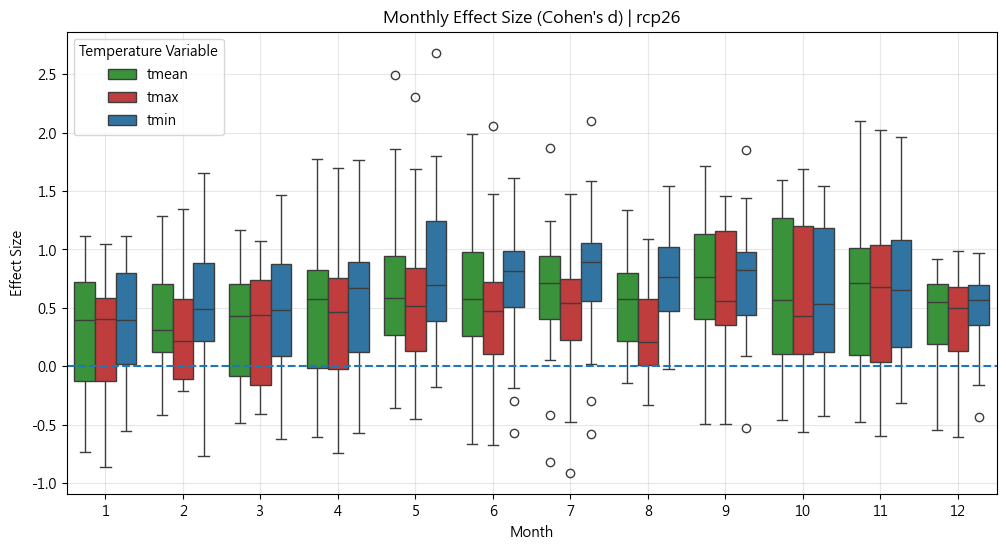

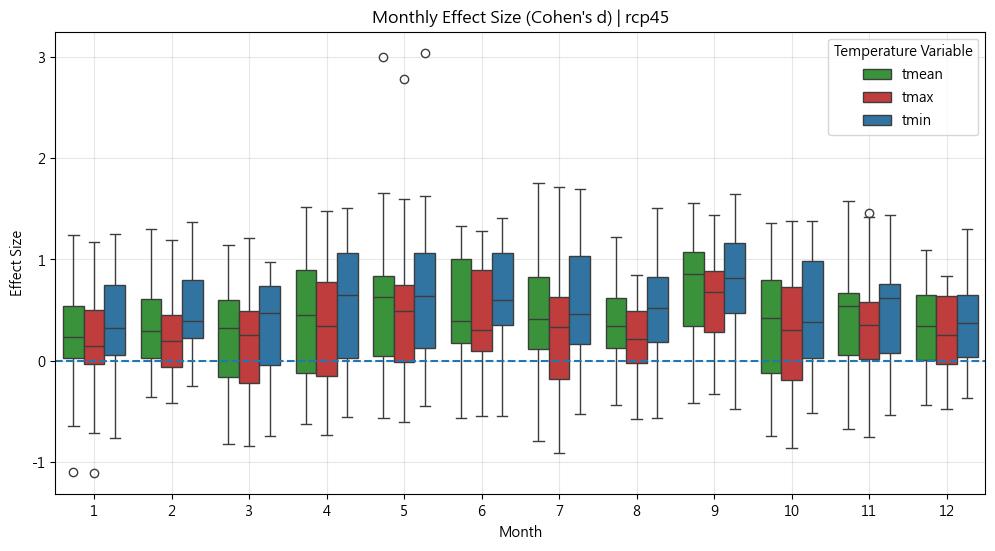

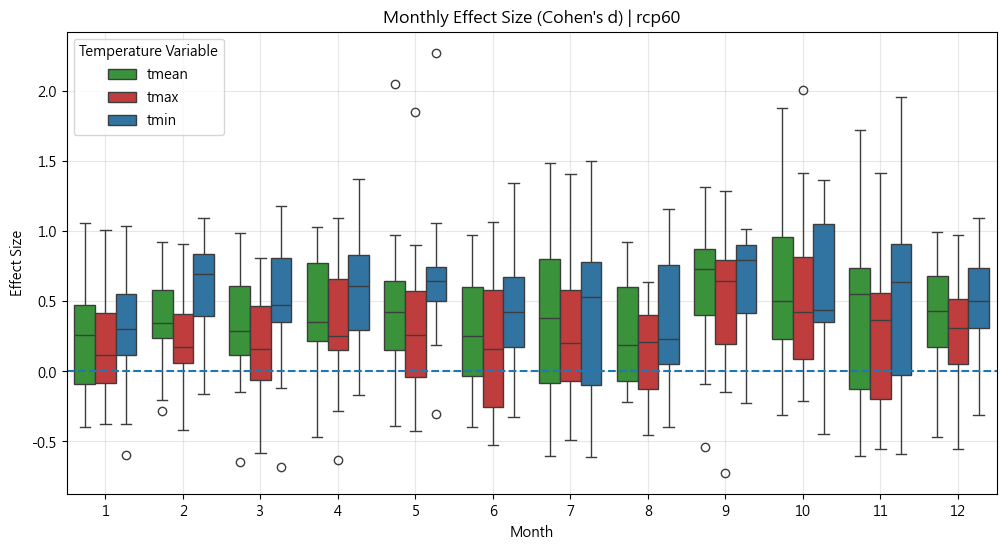

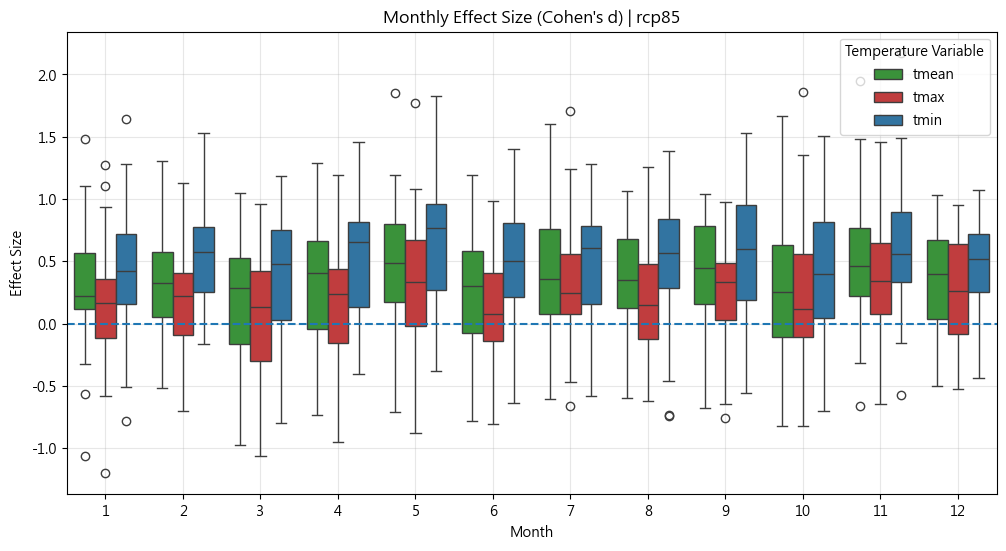

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

output_dir= Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels")
output_dir.mkdir(exist_ok=True)
colors = {
    "tmin": "tab:blue",
    "tmean": "tab:green",
    "tmax": "tab:red"
}

for rcp in ["rcp26", "rcp45", "rcp60", "rcp85"]:
    
    plt.figure(figsize=(12,6))
    
    df_plot = df_es_all[df_es_all["rcp"] == rcp]
    
    sns.boxplot(
        data=df_plot,
        x="month",
        y="effect_size",
        hue="variable",
        palette=colors
    )
    
    plt.axhline(0, linestyle="--")
    
    plt.title(f"Monthly Effect Size (Cohen's d) | {rcp}")
    plt.xlabel("Month")
    plt.ylabel("Effect Size")
    
    plt.legend(title="Temperature Variable")
    plt.grid(alpha=0.3)
    outpath = output_dir / f"Monthly Effect Size (Cohen's d)  {rcp}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

rcp60 總筆數: 540


,variable,aggregation,month,model,rcp,hist_n,fut_n,mean_diff,p_value,significant
564,tmean,monthly_by_month,1,CCSM4,rcp60,6,31,0.685720,0.336592,False
565,tmean,monthly_by_month,2,CCSM4,rcp60,6,31,0.726490,0.079391,False
566,tmean,monthly_by_month,3,CCSM4,rcp60,6,31,-0.856589,0.290926,False
567,tmean,monthly_by_month,4,CCSM4,rcp60,6,31,-0.255872,0.725126,False
568,tmean,monthly_by_month,5,CCSM4,rcp60,6,31,0.742117,0.046352,True


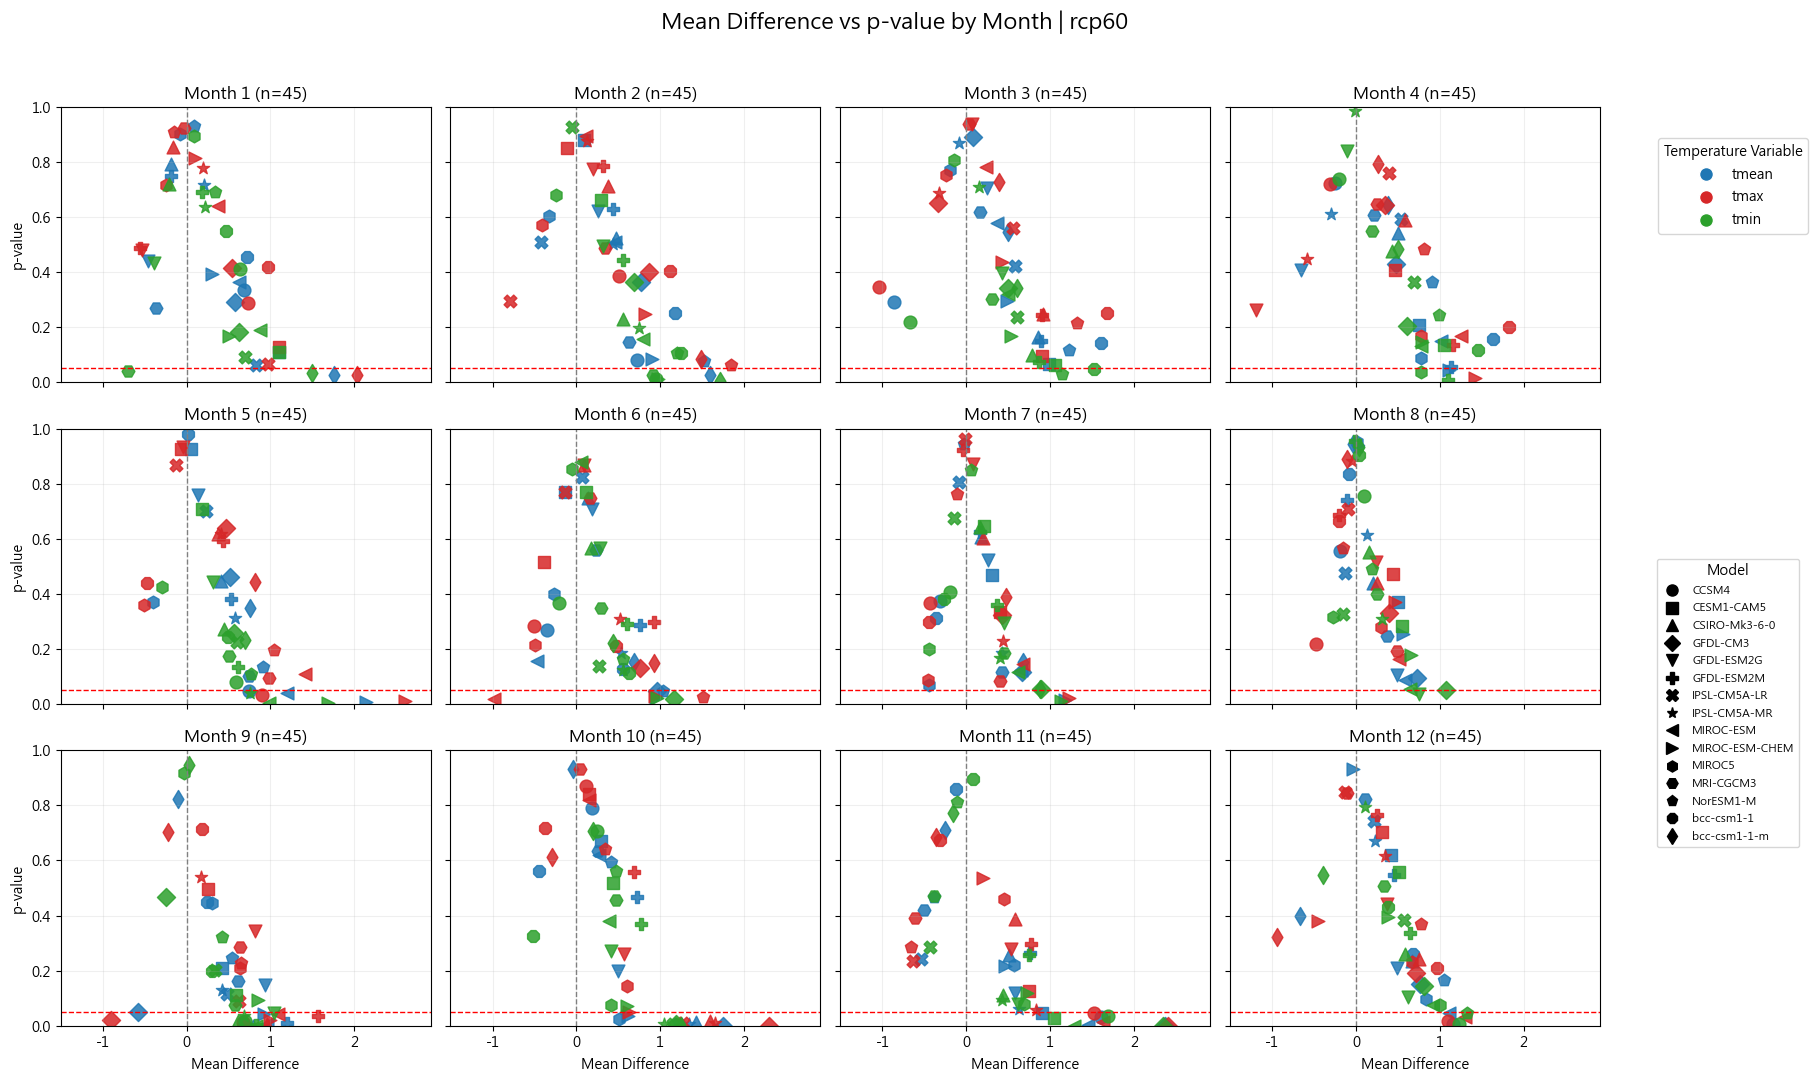

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================================
# 1. 合併三個溫度變數的逐月結果
# =====================================
df_tmean_plot = df_tmean_monthly_by_month.copy()
df_tmax_plot  = df_tmax_monthly_by_month.copy()
df_tmin_plot  = df_tmin_monthly_by_month.copy()

# 保險起見，補 variable 欄位
df_tmean_plot["variable"] = "tmean"
df_tmax_plot["variable"]  = "tmax"
df_tmin_plot["variable"]  = "tmin"

plot_df = pd.concat(
    [df_tmean_plot, df_tmax_plot, df_tmin_plot],
    ignore_index=True
)

# 數值欄位保險轉型
plot_df["mean_diff"] = pd.to_numeric(plot_df["mean_diff"], errors="coerce")
plot_df["p_value"]   = pd.to_numeric(plot_df["p_value"], errors="coerce")

# =====================================
# 2. 指定 RCP
# =====================================
target_rcp = "rcp60"   # 改成 rcp26 / rcp45 / rcp60 / rcp85

sub_rcp = plot_df[plot_df["rcp"] == target_rcp].copy()

print(f"{target_rcp} 總筆數: {len(sub_rcp)}")
display(sub_rcp.head())

# =====================================
# 3. 顏色與形狀設定
# =====================================
# 溫度變數 -> 顏色
color_map = {
    "tmean": "tab:blue",
    "tmax":  "tab:red",
    "tmin":  "tab:green"
}

# 模型 -> 形狀
all_models = sorted(sub_rcp["model"].dropna().unique())

marker_list = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
    "p", "8", "d", "|", "_", "+", "x", "1", "2", "3", "4"
]

marker_map = {
    model: marker_list[i % len(marker_list)]
    for i, model in enumerate(all_models)
}

# =====================================
# 4. 統一座標範圍
# =====================================
x_min = np.nanmin(sub_rcp["mean_diff"])
x_max = np.nanmax(sub_rcp["mean_diff"])
y_min = 0
y_max = min(1.0, np.nanmax(sub_rcp["p_value"]) * 1.05)

x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 0.1
x_min_plot = x_min - x_pad
x_max_plot = x_max + x_pad

# =====================================
# 5. 畫 12 張小圖（1~12 月）
# =====================================
fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.flatten()

for m in range(1, 13):
    ax = axes[m - 1]
    sub = sub_rcp[sub_rcp["month"] == m].copy()

    for _, row in sub.iterrows():
        ax.scatter(
            row["mean_diff"],
            row["p_value"],
            color=color_map.get(row["variable"], "gray"),
            marker=marker_map.get(row["model"], "o"),
            s=85,
            alpha=0.85
        )

    # 顯著門檻與零差線
    ax.axhline(0.05, linestyle="--", color="red", linewidth=1)
    ax.axvline(0, linestyle="--", color="gray", linewidth=1)

    ax.set_title(f"Month {m} (n={len(sub)})")
    ax.set_xlim(x_min_plot, x_max_plot)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.2)

# 座標標籤
for i in [0, 4, 8]:
    axes[i].set_ylabel("p-value")
for i in [8, 9, 10, 11]:
    axes[i].set_xlabel("Mean Difference")

fig.suptitle(f"Mean Difference vs p-value by Month | {target_rcp}", fontsize=16, y=0.98)

# =====================================
# 6. 圖例：溫度變數
# =====================================
variable_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor=color_map[var],
           markersize=10,
           label=var)
    for var in ["tmean", "tmax", "tmin"]
]

# =====================================
# 7. 圖例：模型形狀
# =====================================
model_handles = [
    Line2D([0], [0],
           marker=marker_map[m],
           color='black',
           linestyle='None',
           markersize=8,
           label=m)
    for m in all_models
]

legend1 = fig.legend(
    handles=variable_handles,
    title="Temperature Variable",
    loc="center left",
    bbox_to_anchor=(0.92, 0.82),
    frameon=True
)

legend2 = fig.legend(
    handles=model_handles,
    title="Model",
    loc="center left",
    bbox_to_anchor=(0.92, 0.35),
    frameon=True,
    fontsize=8,
    ncol=1
)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
outpath = output_dir / f"Mean Difference vs p-value by Month {target_rcp}.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

In [75]:
df_ttest_tmean["aggregation"] = "annual"
df_ttest_tmax["aggregation"] = "annual"
df_ttest_tmin["aggregation"] = "annual"

In [93]:
compare_tmean = (
    df_tmean_monthly_by_month[["model", "rcp", "month", "mean_diff", "p_value", "significant"]]
    .rename(columns={
        "mean_diff": "mean_diff_monthly",
        "p_value": "p_value_monthly",
        "significant": "significant_monthly"
    })
    .merge(
        df_ttest_tmean[["model", "rcp", "mean_diff", "p_value", "significant"]],
        on=["model", "rcp"],
        how="left"
    )
    .rename(columns={
        "mean_diff": "mean_diff_annual",
        "p_value": "p_value_annual",
        "significant": "significant_annual"
    })
)

summary_compare_tmean = compare_tmean.copy()
summary_compare_tmean["delta_p"] = (
    summary_compare_tmean["p_value_monthly"] - summary_compare_tmean["p_value_annual"]
)
summary_compare_tmean["delta_mean_diff"] = (
    summary_compare_tmean["mean_diff_monthly"] - summary_compare_tmean["mean_diff_annual"]
)

print("月平均 - 年平均 的 p-value 平均差：", summary_compare_tmean["delta_p"].mean())
print("月平均 - 年平均 的 mean_diff 平均差：", summary_compare_tmean["delta_mean_diff"].mean())

print("\n年平均顯著筆數：", summary_compare_tmean["significant_annual"].sum())
print("月平均顯著筆數：", summary_compare_tmean["significant_monthly"].sum())

display(summary_compare_tmean.head(20))

月平均 - 年平均 的 p-value 平均差： 0.18057373011578703
月平均 - 年平均 的 mean_diff 平均差： 0.0011923220939770822

年平均顯著筆數： 384
月平均顯著筆數： 187


,model,rcp,month,mean_diff_monthly,p_value_monthly,significant_monthly,mean_diff_annual,p_value_annual,significant_annual,delta_p,delta_mean_diff
0,BNU-ESM,rcp26,1,-0.118550,0.721785,False,0.335679,0.173593,False,0.548192,-0.454229
1,BNU-ESM,rcp26,2,-0.178308,0.760147,False,0.335679,0.173593,False,0.586553,-0.513987
2,BNU-ESM,rcp26,3,-0.180919,0.753839,False,0.335679,0.173593,False,0.580245,-0.516598
3,BNU-ESM,rcp26,4,-0.723880,0.203901,False,0.335679,0.173593,False,0.030308,-1.059559
4,BNU-ESM,rcp26,5,0.248927,0.467263,False,0.335679,0.173593,False,0.293669,-0.086752
5,BNU-ESM,rcp26,6,0.696977,0.112939,False,0.335679,0.173593,False,-0.060655,0.361298
6,BNU-ESM,rcp26,7,0.807513,0.203706,False,0.335679,0.173593,False,0.030113,0.471834
7,BNU-ESM,rcp26,8,0.619243,0.106257,False,0.335679,0.173593,False,-0.067337,0.283564
8,BNU-ESM,rcp26,9,0.998072,0.029208,True,0.335679,0.173593,False,-0.144385,0.662392
9,BNU-ESM,rcp26,10,-0.022154,0.964290,False,0.335679,0.173593,False,0.790696,-0.357833


In [94]:
monthly_sig_summary = (
    summary_compare_tmean.groupby("month")[["significant_monthly"]]
    .sum()
    .reset_index()
)

display(monthly_sig_summary)

,month,significant_monthly
0,1,13
1,2,8
2,3,7
3,4,11
4,5,18
5,6,19
6,7,13
7,8,11
8,9,29
9,10,25


In [98]:
import pandas as pd

def get_monthly_stats(df, var_name):
    summary = (
        df.groupby("month")
        .agg(
            sig_count=("significant", "sum"),
            total=("significant", "count")
        )
        .reset_index()
    )
    summary["variable"] = var_name
    return summary

df_stat_tmin  = get_monthly_stats(df_tmin_monthly_by_month, "tmin")
df_stat_tmean = get_monthly_stats(df_tmean_monthly_by_month, "tmean")
df_stat_tmax  = get_monthly_stats(df_tmax_monthly_by_month, "tmax")

df_stat_all = pd.concat([df_stat_tmin, df_stat_tmean, df_stat_tmax], ignore_index=True)

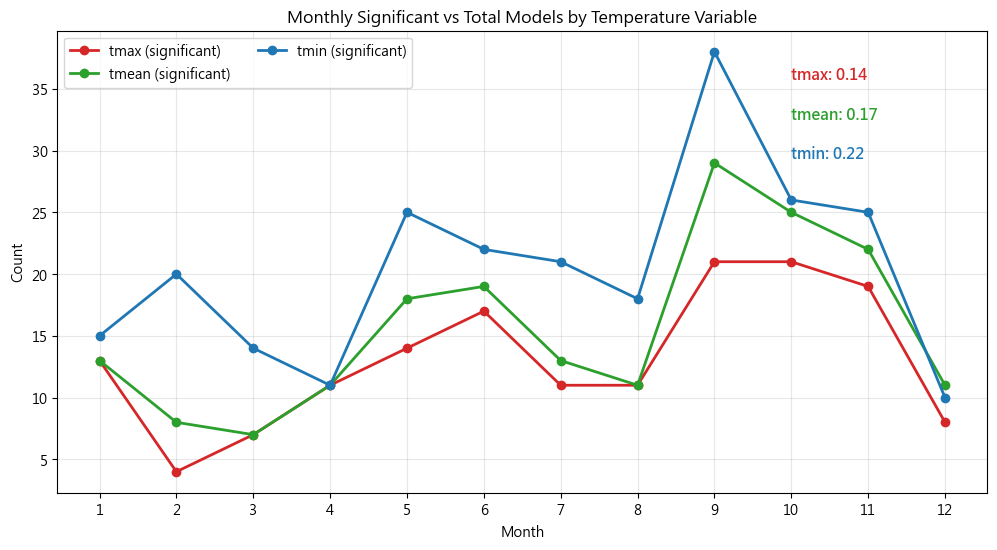

In [105]:

# ===== 畫圖 =====
plt.figure(figsize=(12,6))

colors = {
    "tmin": "tab:blue",
    "tmean": "tab:green",
    "tmax": "tab:red"
}

ratio_texts = []

for var, sub in df_stat_all.groupby("variable"):
    color = colors[var]

    # 實線：顯著數
    plt.plot(
        sub["month"],
        sub["sig_count"],
        marker="o",
        linewidth=2,
        color=color,
        label=f"{var} (significant)"
    )


    # ===== 計算整體比例 =====
    total_sig = sub["sig_count"].sum()
    total_all = sub["total"].sum()
    ratio = total_sig / total_all if total_all > 0 else 0

    ratio_texts.append((var, ratio))


# ===== 軸設定 =====
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Monthly Significant vs Total Models by Temperature Variable")

plt.legend(ncol=2)
plt.grid(alpha=0.3)


# ===== 在圖上放比例（重點）=====
y_max = plt.gca().get_ylim()[1]

for i, (var, ratio) in enumerate(ratio_texts):
    plt.text(
        10,                     # x位置（右側空白）
        y_max * (0.9 - i*0.08),  # y位置（往下排）
        f"{var}: {ratio:.2f}",
        color=colors[var],
        fontsize=11,
        fontweight="bold"
    )

outpath = output_dir / "Monthly Significant vs Total Models by Temperature Variable.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")


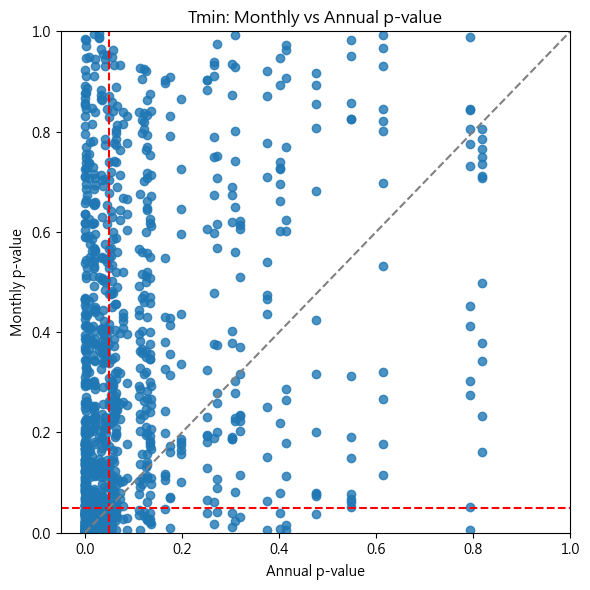

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    compare_tmean["p_value_annual"],
    compare_tmean["p_value_monthly"],
    alpha=0.8
)

plt.axhline(0.05, linestyle="--", color="red")
plt.axvline(0.05, linestyle="--", color="red")

lims = [0, 1]
plt.plot(lims, lims, linestyle="--", color="gray")

plt.xlim([-0.05,1.0])
plt.ylim(lims)

plt.xlabel("Annual p-value")
plt.ylabel("Monthly p-value")
plt.title("Tmin: Monthly vs Annual p-value")
plt.tight_layout()
plt.show()

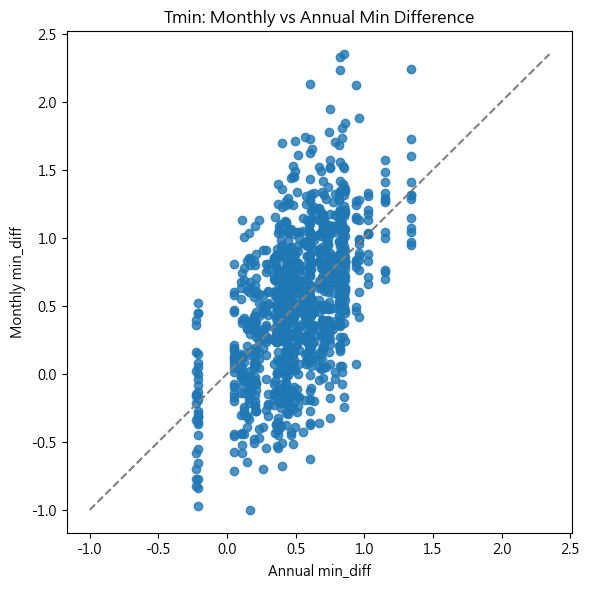

In [82]:
plt.figure(figsize=(6, 6))

plt.scatter(
    compare_tmean["mean_diff_annual"],
    compare_tmean["mean_diff_monthly"],
    alpha=0.8
)

lims = [
    min(compare_tmean["mean_diff_annual"].min(), compare_tmean["mean_diff_monthly"].min()),
    max(compare_tmean["mean_diff_annual"].max(), compare_tmean["mean_diff_monthly"].max())
]
plt.plot(lims, lims, linestyle="--", color="gray")

plt.xlabel("Annual min_diff")
plt.ylabel("Monthly min_diff")
plt.title("Tmin: Monthly vs Annual Min Difference")
plt.tight_layout()
plt.show()

In [37]:
hist_start = 2000
hist_end   = 2005
fut_start  = 2006
fut_end    = 2036

df_ttest_tmean, annual_tmean_df, daily_tmean_df, year_count_tmean_df = run_ttest_for_variable(
    variable_key="tmean",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_ttest_tmax, annual_tmax_df, daily_tmax_df, year_count_tmax_df = run_ttest_for_variable(
    variable_key="tmax",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)

df_ttest_tmin, annual_tmin_df, daily_tmin_df, year_count_tmin_df = run_ttest_for_variable(
    variable_key="tmin",
    final_models_by_rcp=final_models_by_rcp,
    hist_start=hist_start,
    hist_end=hist_end,
    fut_start=fut_start,
    fut_end=fut_end,
    poi_lat=POI_LAT,
    poi_lon=POI_LON
)


===== Running tmean =====
需要讀取的模式數: 31

=== 建立 tmean daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_平均溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK] ACCESS1-0 | rcp45 | 2015
[OK] ACCESS1-0 | rcp45 | 2016
[OK] ACCESS1-0 | rcp45 | 2017
[OK] ACCESS1-0 | rcp45 | 2018
[OK] ACCESS1-0 | rcp45 | 2019
[OK] ACCESS1-0 | rcp45 | 2020
[OK] ACCESS1-0 | rcp45 | 2021
[OK] ACCESS1-0 | rcp45 | 2022
[OK] ACCESS1-0 | rcp45 | 2023
[OK] ACCESS1-0 | rcp45 | 2024
[OK] ACCESS1-0 | rcp45 | 2025
[OK] ACCESS1-0 | rcp45 | 2026
[OK] ACCESS1-0 | rcp45 | 2

df_ttest_all 建立完成


,variable,model,rcp,hist_n,fut_n,hist_mean,fut_mean,mean_diff,t_stat,p_value,significant
0,tmean,BNU-ESM,rcp26,6,31,23.534191,23.869870,0.335679,-1.511889,0.173593,False
1,tmean,CCSM4,rcp26,6,31,23.334977,23.634093,0.299116,-2.276115,0.040693,True
2,tmean,CESM1-CAM5,rcp26,6,31,22.926083,23.732355,0.806273,-2.388183,0.052637,False
3,tmean,CNRM-CM5,rcp26,6,31,23.719073,23.434462,-0.284612,1.163246,0.283111,False
4,tmean,CSIRO-Mk3-6-0,rcp26,6,31,23.095126,24.253077,1.157951,-3.896040,0.002904,True


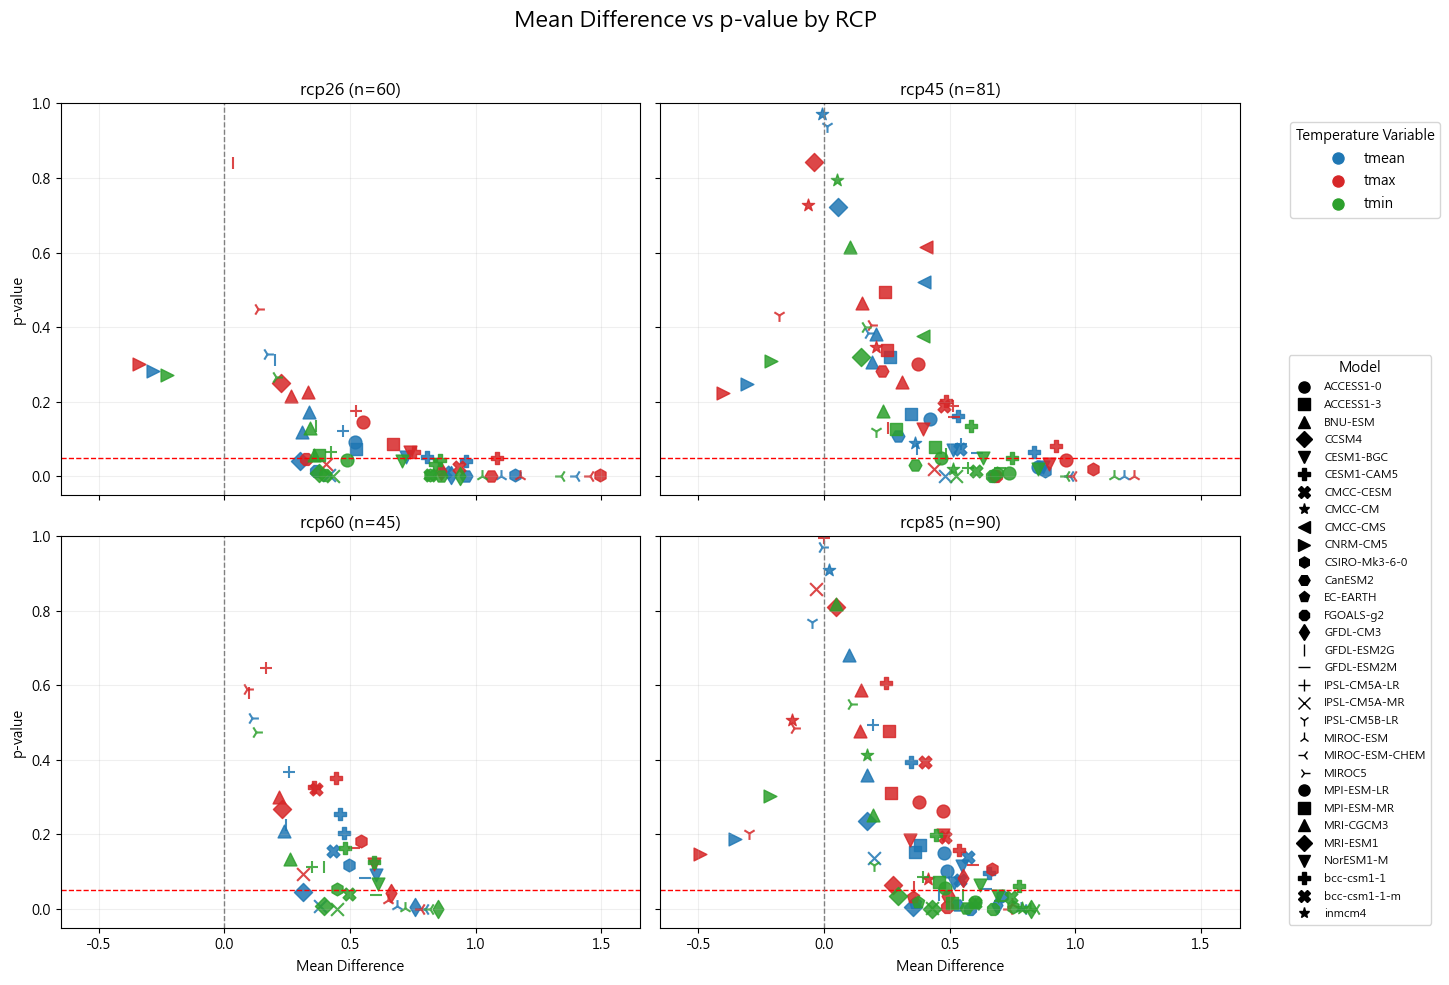

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd

df_ttest_all = pd.concat(
    [df_ttest_tmean, df_ttest_tmax, df_ttest_tmin],
    ignore_index=True
)

print("df_ttest_all 建立完成")
display(df_ttest_all.head())
# -------------------------
# 0. 基本資料檢查
# -------------------------
plot_df = df_ttest_all.copy()
plot_df["mean_diff"] = pd.to_numeric(plot_df["mean_diff"], errors="coerce")
plot_df["p_value"] = pd.to_numeric(plot_df["p_value"], errors="coerce")

# 固定順序
rcp_order = ["rcp26", "rcp45", "rcp60", "rcp85"]
var_order = ["tmean", "tmax", "tmin"]

# -------------------------
# 1. 顏色：溫度變數
# -------------------------
color_map = {
    "tmean": "tab:blue",
    "tmax":  "tab:red",
    "tmin":  "tab:green"
}

# -------------------------
# 2. 形狀：model
# -------------------------
all_models = sorted(plot_df["model"].dropna().unique())

marker_list = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
    "p", "8", "d", "|", "_", "+", "x", "1", "2", "3", "4"
]

marker_map = {
    model: marker_list[i % len(marker_list)]
    for i, model in enumerate(all_models)
}

# -------------------------
# 3. 統一座標範圍
# -------------------------
x_min = np.nanmin(plot_df["mean_diff"])
x_max = np.nanmax(plot_df["mean_diff"])
y_min = -0.05
y_max = min(1.0, np.nanmax(plot_df["p_value"]) * 1.05)

# 給左右留點空間
x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 0.1
x_min_plot = x_min - x_pad
x_max_plot = x_max + x_pad

# -------------------------
# 4. 建圖
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, rcp in zip(axes, rcp_order):
    sub = plot_df[plot_df["rcp"] == rcp].copy()

    for _, row in sub.iterrows():
        ax.scatter(
            row["mean_diff"],
            row["p_value"],
            color=color_map.get(row["variable"], "gray"),
            marker=marker_map.get(row["model"], "o"),
            s=85,
            alpha=0.85
        )

    # 顯著線與零差線
    ax.axhline(0.05, linestyle="--", color="red", linewidth=1)
    ax.axvline(0, linestyle="--", color="gray", linewidth=1)

    ax.set_title(f"{rcp} (n={len(sub)})")
    ax.set_xlim(x_min_plot, x_max_plot)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.2)

# 座標標題
axes[0].set_ylabel("p-value")
axes[2].set_ylabel("p-value")
axes[2].set_xlabel("Mean Difference")
axes[3].set_xlabel("Mean Difference")

fig.suptitle("Mean Difference vs p-value by RCP", fontsize=16, y=0.98)

# -------------------------
# 5. 圖例：顏色 = variable
# -------------------------
variable_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor=color_map[var],
           markersize=10,
           label=var)
    for var in var_order
]

# -------------------------
# 6. 圖例：形狀 = model
# -------------------------
model_handles = [
    Line2D([0], [0],
           marker=marker_map[m],
           color='black',
           linestyle='None',
           markersize=8,
           label=m)
    for m in all_models
]

legend1 = fig.legend(
    handles=variable_handles,
    title="Temperature Variable",
    loc="center left",
    bbox_to_anchor=(0.92, 0.82),
    frameon=True
)

legend2 = fig.legend(
    handles=model_handles,
    title="Model",
    loc="center left",
    bbox_to_anchor=(0.92, 0.35),
    frameon=True,
    fontsize=8,
    ncol=1
)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
outpath = output_dir / "Mean Difference vs p-value by RCP.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()